Predicted class: lion
Confidence: 71.84%

All probabilities:
lion: 71.84%
wolf: 25.90%
cheetah: 2.27%
tiger: 0.00%
fox: 0.00%
hyena: 0.00%


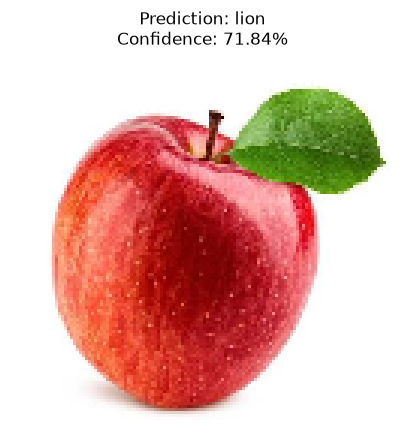

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# Load the trained model
model = tf.keras.models.load_model(
    "./resultsSaved/multiclass/VGG19/vgg19_multiclass_classifier.keras"
)

# Change this to the image you want to predict
IMAGE_PATH = Path("./test_images/fox.jpeg")

# Settings must match the training notebook
IMAGE_SIZE = 128

class_names = [
    "cheetah",
    "fox",
    "hyena",
    "lion",
    "tiger",
    "wolf",
]

if not IMAGE_PATH.exists():
    raise FileNotFoundError(
        f"Image not found: {IMAGE_PATH.resolve()}"
    )


# Load and resize the image
image = tf.keras.utils.load_img(
    IMAGE_PATH,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
)

# Convert the image to an array
image_array = tf.keras.utils.img_to_array(image)

# Add the batch dimension
image_batch = np.expand_dims(image_array, axis=0)

# Apply VGG19 preprocessing explicitly
processed_image = tf.keras.applications.vgg19.preprocess_input(
    image_batch.copy()
)

# Predict probabilities
probabilities = model.predict(
    processed_image,
    verbose=0,
)[0]

# Find the class with the highest probability
predicted_index = np.argmax(probabilities)
predicted_class = class_names[predicted_index]
confidence = probabilities[predicted_index]


print("Predicted class:", predicted_class)
print(f"Confidence: {confidence:.2%}")

print("\nAll probabilities:")

for class_name, probability in sorted(
    zip(class_names, probabilities),
    key=lambda item: item[1],
    reverse=True,
):
    print(f"{class_name}: {probability:.2%}")


plt.figure(figsize=(6, 5))
plt.imshow(image)
plt.title(
    f"Prediction: {predicted_class}\n"
    f"Confidence: {confidence:.2%}"
)
plt.axis("off")
plt.show()